# Phase 1: Data Profiling & Exploration
## End-to-End Healthcare Data Analytics Project

**Dataset:** Synthea Synthetic Patient Data (April 2020 Release)  
**Objective:** Profile all 16 CSV files — understand structure, data quality, relationships, and scope before analysis.

---

### 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DATA_PATH = '../../data/raw/'

print("Environment ready.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Environment ready.
Pandas version: 3.0.1
NumPy version: 2.4.2


### 2. Load All Datasets

Load every CSV into a dictionary of DataFrames for systematic profiling.

In [2]:
# Load all CSV files into a dictionary
csv_files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('.csv')])
datasets = {}

for f in csv_files:
    name = f.replace('.csv', '')
    datasets[name] = pd.read_csv(os.path.join(DATA_PATH, f))

print(f"Loaded {len(datasets)} datasets:\n")
for name, df in datasets.items():
    print(f"  {name:25s} → {df.shape[0]:>7,} rows  |  {df.shape[1]:>2} columns")

Loaded 16 datasets:

  allergies                 →     597 rows  |   6 columns
  careplans                 →   3,483 rows  |   9 columns
  conditions                →   8,376 rows  |   6 columns
  devices                   →      78 rows  |   7 columns
  encounters                →  53,346 rows  |  15 columns
  imaging_studies           →     855 rows  |  10 columns
  immunizations             →  15,478 rows  |   6 columns
  medications               →  42,989 rows  |  13 columns
  observations              → 299,697 rows  |   8 columns
  organizations             →   1,119 rows  |  11 columns
  patients                  →   1,171 rows  |  25 columns
  payer_transitions         →   3,801 rows  |   5 columns
  payers                    →      10 rows  |  21 columns
  procedures                →  34,981 rows  |   8 columns
  providers                 →   5,855 rows  |  12 columns
  supplies                  →       0 rows  |   6 columns


### 3. Data Inventory Summary

A consolidated view of every table — row counts, columns, memory usage, and null percentages.

In [3]:
# Build inventory table
inventory = []
for name, df in datasets.items():
    inventory.append({
        'Table': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Memory (KB)': round(df.memory_usage(deep=True).sum() / 1024, 1),
        'Null Cells': df.isnull().sum().sum(),
        'Null %': round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2) if df.shape[0] > 0 else 0,
        'Column Names': ', '.join(df.columns.tolist())
    })

inventory_df = pd.DataFrame(inventory).sort_values('Rows', ascending=False)
inventory_df.reset_index(drop=True, inplace=True)

# Display without column names for clean view
print(inventory_df[['Table', 'Rows', 'Columns', 'Memory (KB)', 'Null Cells', 'Null %']].to_string(index=False))

            Table   Rows  Columns  Memory (KB)  Null Cells  Null %
     observations 299697        8     153755.8       43098    1.80
       encounters  53346       15      40799.2       79138    9.89
      medications  42989       13      25006.5       24129    4.32
       procedures  34981        8      13531.7       31088   11.11
    immunizations  15478        6       5154.1           0    0.00
       conditions   8376        6       2925.1        3811    7.58
        providers   5855       12       3486.8           0    0.00
payer_transitions   3801        5        886.4         236    1.24
        careplans   3483        9       1761.0        2186    6.97
         patients   1171       25       1326.5        4652   15.89
    organizations   1119       11        516.8         184    1.49
  imaging_studies    855       10        568.5           0    0.00
        allergies    597        6        198.4         533   14.88
          devices     78        7         35.9          78   1

#### 3a. Dataset Size Comparison

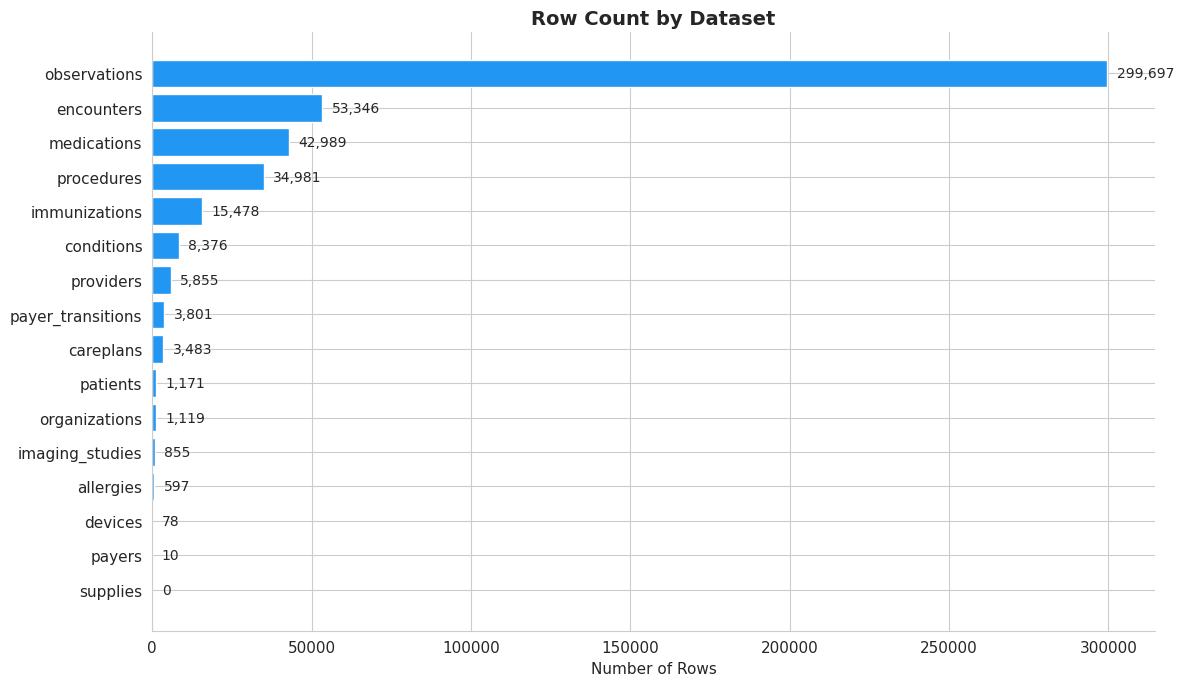

Saved: images/01_dataset_row_counts.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
plot_df = inventory_df.sort_values('Rows', ascending=True)
bars = ax.barh(plot_df['Table'], plot_df['Rows'], color='#2196F3', edgecolor='white')

# Add value labels
for bar, val in zip(bars, plot_df['Rows']):
    ax.text(bar.get_width() + max(plot_df['Rows'])*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Number of Rows')
ax.set_title('Row Count by Dataset', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../../images/01_dataset_row_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/01_dataset_row_counts.png")

### 4. Detailed Column Profiling

For each dataset, examine data types, null counts, unique values, and sample values.

In [5]:
def profile_table(name, df):
    """Generate a detailed column-level profile for a DataFrame."""
    print(f"\n{'='*70}")
    print(f"  TABLE: {name.upper()}  ({df.shape[0]:,} rows × {df.shape[1]} columns)")
    print(f"{'='*70}")
    
    profile = []
    for col in df.columns:
        profile.append({
            'Column': col,
            'Dtype': str(df[col].dtype),
            'Non-Null': df[col].notna().sum(),
            'Null': df[col].isna().sum(),
            'Null %': round(df[col].isna().mean() * 100, 1),
            'Unique': df[col].nunique(),
            'Sample Value': str(df[col].dropna().iloc[0])[:50] if df[col].notna().any() else 'N/A'
        })
    
    profile_df = pd.DataFrame(profile)
    print(profile_df.to_string(index=False))
    return profile_df

# Profile each table
all_profiles = {}
for name, df in datasets.items():
    if df.shape[0] > 0:  # skip empty tables
        all_profiles[name] = profile_table(name, df)


  TABLE: ALLERGIES  (597 rows × 6 columns)
     Column Dtype  Non-Null  Null  Null %  Unique                         Sample Value
      START   str       597     0     0.0     141                           1982-10-25
       STOP   str        64   533    89.3      29                           2014-03-20
    PATIENT   str       597     0     0.0     141 76982e06-f8b8-4509-9ca3-65a99c8650fe
  ENCOUNTER   str       597     0     0.0     141 b896bf40-8b72-42b7-b205-142ee3a56b55
       CODE int64       597     0     0.0      15                            300916003
DESCRIPTION   str       597     0     0.0      15                        Latex allergy

  TABLE: CAREPLANS  (3,483 rows × 9 columns)
           Column   Dtype  Non-Null  Null  Null %  Unique                         Sample Value
               Id     str      3483     0     0.0    3483 d2500b8c-e830-433a-8b9d-368d30741520
            START     str      3483     0     0.0    2921                           2010-01-23
             STO

             Column   Dtype  Non-Null  Null  Null %  Unique                         Sample Value
                 Id     str     53346     0     0.0   53346 d0c40d10-8d87-447e-836e-99d26ad52ea5
              START     str     53346     0     0.0   50029                 2010-01-23T17:45:28Z
               STOP     str     53346     0     0.0   52461                 2010-01-23T18:10:28Z
            PATIENT     str     53346     0     0.0    1171 034e9e3b-2def-4559-bb2a-7850888ae060
       ORGANIZATION     str     53346     0     0.0    1103 e002090d-4e92-300e-b41e-7d1f21dee4c6
           PROVIDER     str     53346     0     0.0    1104 e6283e46-fd81-3611-9459-0edb1c3da357
              PAYER     str     53346     0     0.0      10 6e2f1a2d-27bd-3701-8d08-dae202c58632
     ENCOUNTERCLASS     str     53346     0     0.0       6                           ambulatory
               CODE   int64     53346     0     0.0      43                            185345009
        DESCRIPTION     str   

     Column Dtype  Non-Null  Null  Null %  Unique                         Sample Value
       DATE   str    299697     0     0.0   29074                 2012-01-23T17:45:28Z
    PATIENT   str    299697     0     0.0    1171 034e9e3b-2def-4559-bb2a-7850888ae060
  ENCOUNTER   str    269334 30363    10.1   20030 e88bc3a9-007c-405e-aabc-792a38f4aa2b
       CODE   str    299697     0     0.0     125                               8302-2
DESCRIPTION   str    299697     0     0.0     129                          Body Height
      VALUE   str    299697     0     0.0    4822                                193.3
      UNITS   str    286962 12735     4.2      34                                   cm
       TYPE   str    299697     0     0.0       2                              numeric

  TABLE: ORGANIZATIONS  (1,119 rows × 11 columns)
     Column   Dtype  Non-Null  Null  Null %  Unique                         Sample Value
         Id     str      1119     0     0.0    1119 ef58ea08-d883-3957-8300-1

### 5. Null Value Analysis

Identify which columns across all tables have missing data — this drives cleaning decisions in Phase 2.

In [6]:
# Collect all columns with nulls
null_summary = []
for name, df in datasets.items():
    for col in df.columns:
        null_count = df[col].isna().sum()
        if null_count > 0:
            null_summary.append({
                'Table': name,
                'Column': col,
                'Null Count': null_count,
                'Null %': round(df[col].isna().mean() * 100, 1),
                'Total Rows': df.shape[0]
            })

null_df = pd.DataFrame(null_summary).sort_values('Null %', ascending=False)

if len(null_df) > 0:
    print(f"Found {len(null_df)} columns with null values across all tables:\n")
    print(null_df.to_string(index=False))
else:
    print("No null values found in any table.")

Found 30 columns with null values across all tables:

            Table              Column  Null Count  Null %  Total Rows
          devices                STOP          78   100.0          78
         patients              SUFFIX        1159    99.0        1171
        allergies                STOP         533    89.3         597
         patients           DEATHDATE        1000    85.4        1171
       encounters   REASONDESCRIPTION       39569    74.2       53346
       encounters          REASONCODE       39569    74.2       53346
         patients              MAIDEN         840    71.7        1171
         patients                 ZIP         543    46.4        1171
       conditions                STOP        3811    45.5        8376
       procedures   REASONDESCRIPTION       15544    44.4       34981
       procedures          REASONCODE       15544    44.4       34981
        careplans                STOP        1532    44.0        3483
         patients             MARITA

#### 5a. Null Percentage Heatmap (Top Tables)

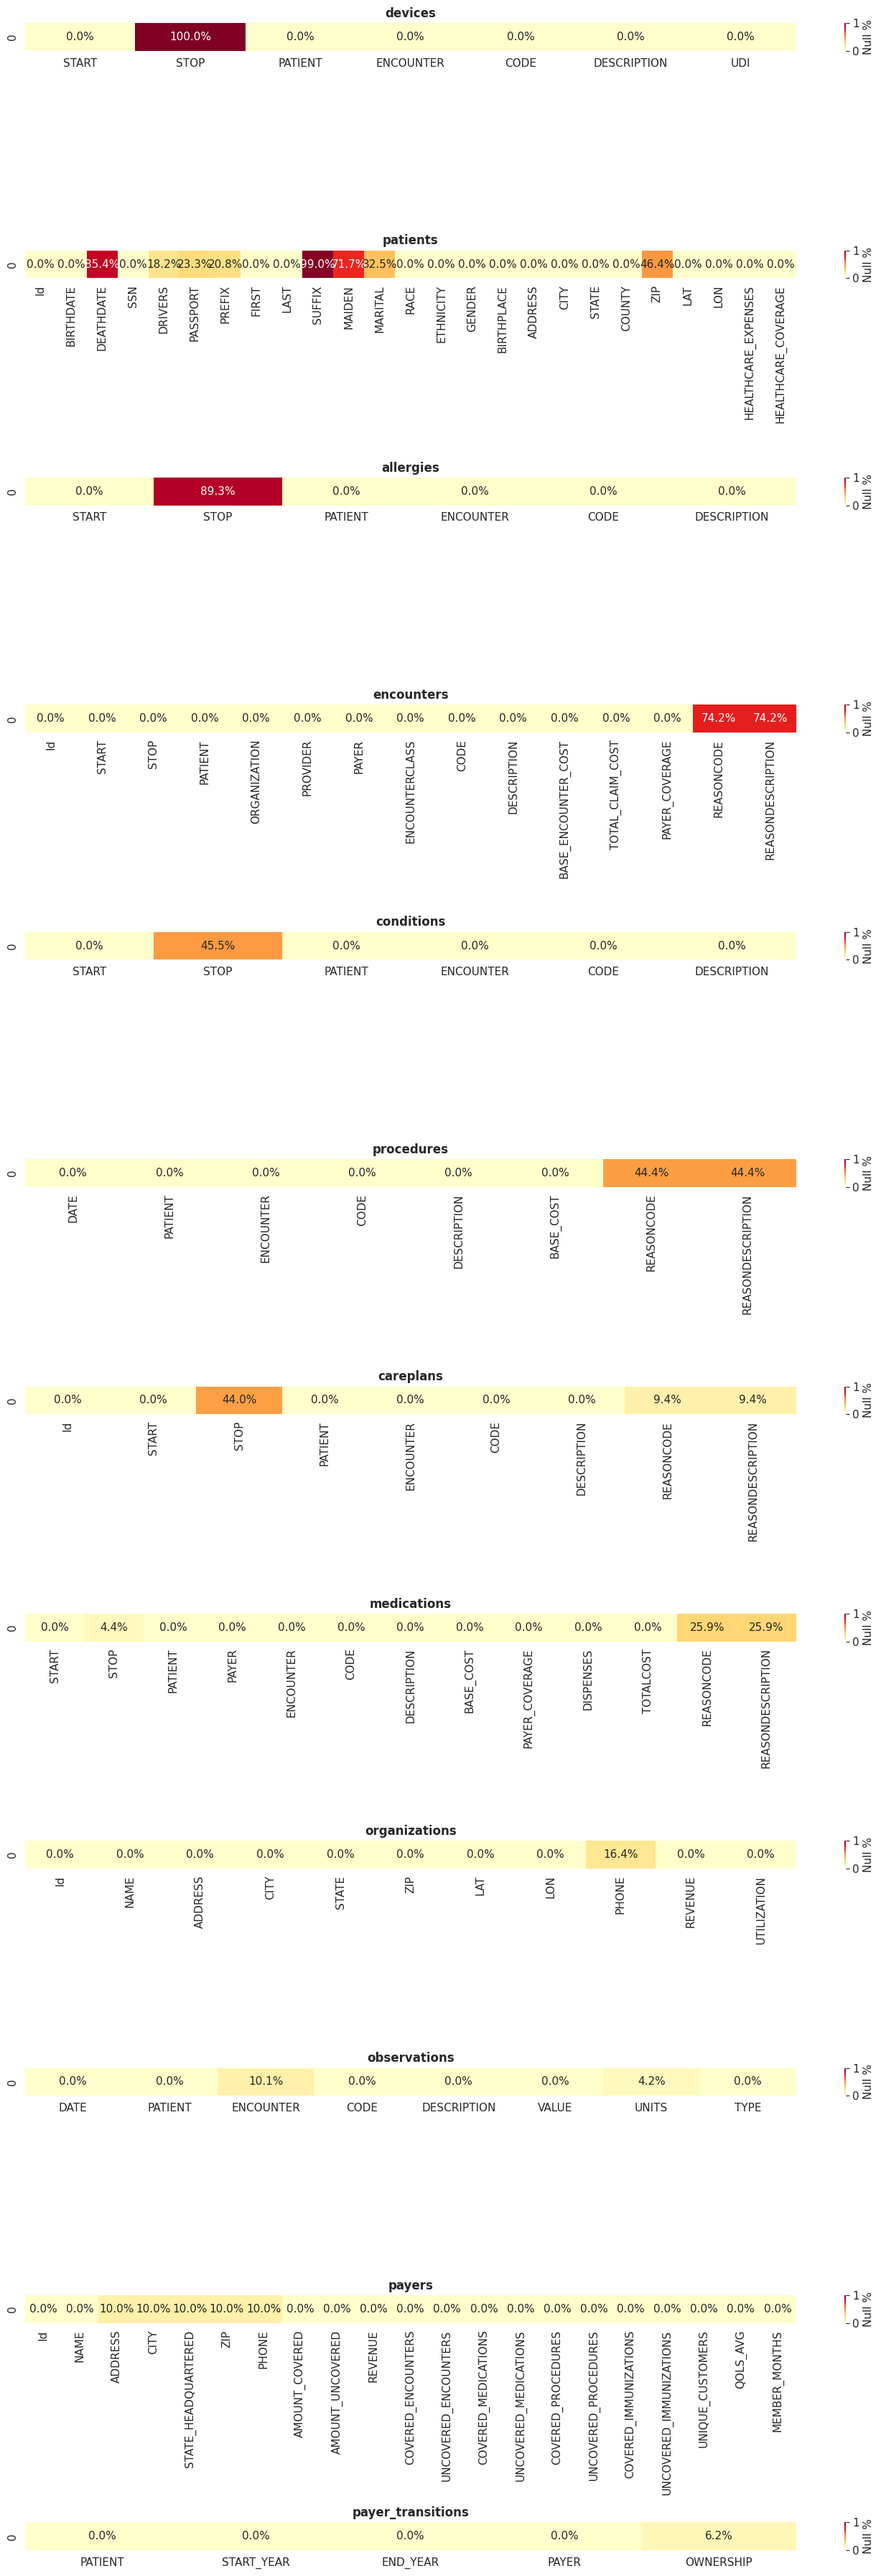

Saved: images/02_null_heatmap.png


In [7]:
# Build null % matrix for tables with nulls
tables_with_nulls = null_df['Table'].unique().tolist() if len(null_df) > 0 else []

if tables_with_nulls:
    fig, axes = plt.subplots(len(tables_with_nulls), 1, 
                              figsize=(14, 3 * len(tables_with_nulls)))
    if len(tables_with_nulls) == 1:
        axes = [axes]
    
    for ax, tbl in zip(axes, tables_with_nulls):
        df = datasets[tbl]
        null_pct = df.isnull().mean().to_frame().T
        sns.heatmap(null_pct, annot=True, fmt='.1%', cmap='YlOrRd', 
                    ax=ax, cbar_kws={'label': 'Null %'}, vmin=0, vmax=1)
        ax.set_title(f'{tbl}', fontsize=12, fontweight='bold')
        ax.set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('../../images/02_null_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: images/02_null_heatmap.png")
else:
    print("No tables with null values to visualize.")

### 6. Date Range Analysis

Understand the time span of the data — critical for temporal analysis in later phases.

In [8]:
# Find and analyze date columns
date_keywords = ['DATE', 'START', 'STOP', 'BIRTHDATE', 'DEATHDATE']

print(f"{'Table':<20} {'Column':<15} {'Min Date':<12} {'Max Date':<12} {'Span (Days)':>12}")
print("-" * 75)

for name, df in datasets.items():
    for col in df.columns:
        if any(kw in col.upper() for kw in date_keywords):
            try:
                dates = pd.to_datetime(df[col], errors='coerce').dropna()
                if len(dates) > 0:
                    print(f"{name:<20} {col:<15} {dates.min().strftime('%Y-%m-%d'):<12} "
                          f"{dates.max().strftime('%Y-%m-%d'):<12} {(dates.max() - dates.min()).days:>12,}")
            except:
                pass

Table                Column          Min Date     Max Date      Span (Days)
---------------------------------------------------------------------------
allergies            START           1912-07-29   2019-12-03         39,208
allergies            STOP            1993-07-10   2020-03-21          9,751
careplans            START           1912-07-21   2020-04-25         39,360
careplans            STOP            1931-11-28   2020-04-26         32,292
conditions           START           1916-12-28   2020-04-25         37,739
conditions           STOP            1917-09-06   2020-04-27         37,489
devices              START           1927-12-15   2018-12-18         33,240
encounters           START           1912-07-21   2020-04-28         39,362
encounters           STOP            1912-07-21   2020-04-28         39,363


imaging_studies      DATE            1930-07-13   2020-03-28         32,765
immunizations        DATE            1945-09-05   2020-04-28         27,264


medications          START           1913-06-17   2020-04-28         39,032
medications          STOP            1913-06-24   2020-04-28         39,025
observations         DATE            1916-05-05   2020-04-28         37,978
patients             BIRTHDATE       1909-12-22   2020-03-22         40,268
patients             DEATHDATE       1926-03-05   2020-03-30         34,359
payer_transitions    START_YEAR      1970-01-01   1970-01-01              0


procedures           DATE            1916-05-05   2020-04-28         37,978


### 7. Entity Relationships & Key Columns

Map how tables connect to each other through shared keys. This is the foundation for SQL JOINs in Phase 2.

**Core Entity Model:**
```
patients (Id) ──┬── encounters (PATIENT → Id, ORGANIZATION, PROVIDER, PAYER)
                 │       ├── conditions (PATIENT, ENCOUNTER)
                 │       ├── medications (PATIENT, ENCOUNTER)
                 │       ├── procedures (PATIENT, ENCOUNTER)
                 │       ├── observations (PATIENT, ENCOUNTER)
                 │       ├── allergies (PATIENT, ENCOUNTER)
                 │       ├── careplans (PATIENT, ENCOUNTER)
                 │       ├── immunizations (PATIENT, ENCOUNTER)
                 │       ├── devices (PATIENT, ENCOUNTER)
                 │       ├── imaging_studies (PATIENT, ENCOUNTER)
                 │       └── supplies (PATIENT, ENCOUNTER)
                 │
organizations (Id) ── providers (ORGANIZATION → Id)
payers (Id) ── payer_transitions (PATIENT, PAYER)
```


In [9]:
# Verify key relationships
print("=== KEY RELATIONSHIP VALIDATION ===\n")

# 1. Patient IDs
patient_ids = set(datasets['patients']['Id'])
print(f"Unique patients: {len(patient_ids):,}")

# 2. Check patient references in other tables
patient_ref_tables = ['encounters', 'conditions', 'medications', 'procedures', 
                       'observations', 'allergies', 'careplans', 'immunizations']

print(f"\n{'Table':<20} {'PATIENT refs':<15} {'In patients?':<15} {'Orphans':>8}")
print("-" * 60)
for tbl in patient_ref_tables:
    if tbl in datasets and 'PATIENT' in datasets[tbl].columns:
        refs = set(datasets[tbl]['PATIENT'])
        orphans = refs - patient_ids
        print(f"{tbl:<20} {len(refs):<15,} {'✓ All match' if not orphans else '✗ ORPHANS':<15} {len(orphans):>8}")

# 3. Encounter references
print(f"\n--- Encounter Key Validation ---")
encounter_ids = set(datasets['encounters']['Id'])
print(f"Unique encounters: {len(encounter_ids):,}")

encounter_ref_tables = ['conditions', 'medications', 'procedures', 'observations']
print(f"\n{'Table':<20} {'ENCOUNTER refs':<15} {'In encounters?':<15} {'Orphans':>8}")
print("-" * 60)
for tbl in encounter_ref_tables:
    if tbl in datasets and 'ENCOUNTER' in datasets[tbl].columns:
        refs = set(datasets[tbl]['ENCOUNTER'])
        orphans = refs - encounter_ids
        print(f"{tbl:<20} {len(refs):<15,} {'✓ All match' if not orphans else '✗ ORPHANS':<15} {len(orphans):>8}")

# 4. Organization and Provider
print(f"\n--- Organization / Provider Validation ---")
org_ids = set(datasets['organizations']['Id'])
prov_orgs = set(datasets['providers']['ORGANIZATION'])
print(f"Organizations: {len(org_ids):,}")
print(f"Provider → Org refs: {len(prov_orgs):,}  |  Orphans: {len(prov_orgs - org_ids)}")

# 5. Payer
payer_ids = set(datasets['payers']['Id'])
enc_payers = set(datasets['encounters']['PAYER'])
print(f"\nPayers: {len(payer_ids):,}")
print(f"Encounter → Payer refs: {len(enc_payers):,}  |  Orphans: {len(enc_payers - payer_ids)}")

=== KEY RELATIONSHIP VALIDATION ===

Unique patients: 1,171

Table                PATIENT refs    In patients?     Orphans
------------------------------------------------------------
encounters           1,171           ✓ All match            0
conditions           1,152           ✓ All match            0
medications          1,107           ✓ All match            0
procedures           1,165           ✓ All match            0


observations         1,171           ✓ All match            0
allergies            141             ✓ All match            0
careplans            1,054           ✓ All match            0
immunizations        1,169           ✓ All match            0

--- Encounter Key Validation ---


Unique encounters: 53,346

Table                ENCOUNTER refs  In encounters?   Orphans
------------------------------------------------------------
conditions           7,650           ✓ All match            0
medications          27,269          ✓ All match            0
procedures           21,072          ✓ All match            0


observations         20,031          ✗ ORPHANS              1

--- Organization / Provider Validation ---
Organizations: 1,119
Provider → Org refs: 1,119  |  Orphans: 0

Payers: 10
Encounter → Payer refs: 10  |  Orphans: 0


### 8. Patient Demographics Overview

Quick demographic snapshot — this informs the segmentation analysis in later phases.

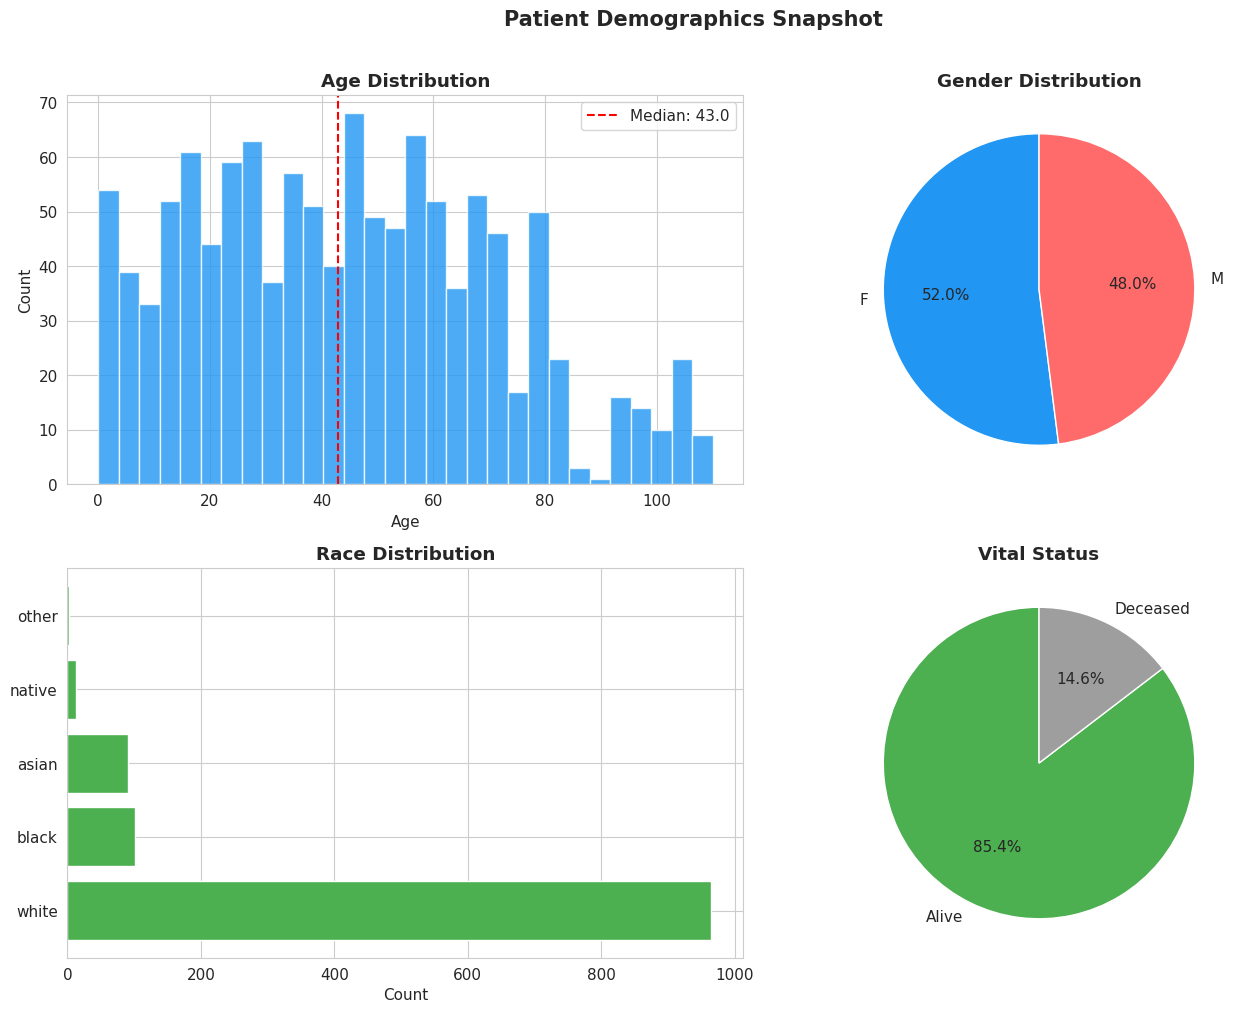


Total patients: 1,171
Alive: 1,000  |  Deceased: 171
Age range: 0 – 110  |  Median: 43.0
Gender: {'F': np.int64(609), 'M': np.int64(562)}

Saved: images/03_patient_demographics.png


In [10]:
patients = datasets['patients'].copy()
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'], errors='coerce')
patients['AGE'] = ((pd.Timestamp('2020-04-01') - patients['BIRTHDATE']).dt.days / 365.25).astype(int)
patients['IS_ALIVE'] = patients['DEATHDATE'].isna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0,0].hist(patients['AGE'], bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Age Distribution', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(patients['AGE'].median(), color='red', linestyle='--', label=f'Median: {patients["AGE"].median()}')
axes[0,0].legend()

# Gender
gender_counts = patients['GENDER'].value_counts()
axes[0,1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
              colors=['#2196F3', '#FF6B6B'], startangle=90)
axes[0,1].set_title('Gender Distribution', fontweight='bold')

# Race
race_counts = patients['RACE'].value_counts()
axes[1,0].barh(race_counts.index, race_counts.values, color='#4CAF50', edgecolor='white')
axes[1,0].set_title('Race Distribution', fontweight='bold')
axes[1,0].set_xlabel('Count')

# Alive vs Deceased
alive_counts = patients['IS_ALIVE'].value_counts()
labels = ['Alive', 'Deceased']
axes[1,1].pie(alive_counts, labels=labels, autopct='%1.1f%%',
              colors=['#4CAF50', '#9E9E9E'], startangle=90)
axes[1,1].set_title('Vital Status', fontweight='bold')

plt.suptitle('Patient Demographics Snapshot', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../images/03_patient_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f"\nTotal patients: {len(patients):,}")
print(f"Alive: {patients['IS_ALIVE'].sum():,}  |  Deceased: {(~patients['IS_ALIVE']).sum():,}")
print(f"Age range: {patients['AGE'].min()} – {patients['AGE'].max()}  |  Median: {patients['AGE'].median()}")
print(f"Gender: {dict(gender_counts)}")
print(f"\nSaved: images/03_patient_demographics.png")

### 9. Encounters Overview

Encounters are the central transactional table — every clinical event flows through here.

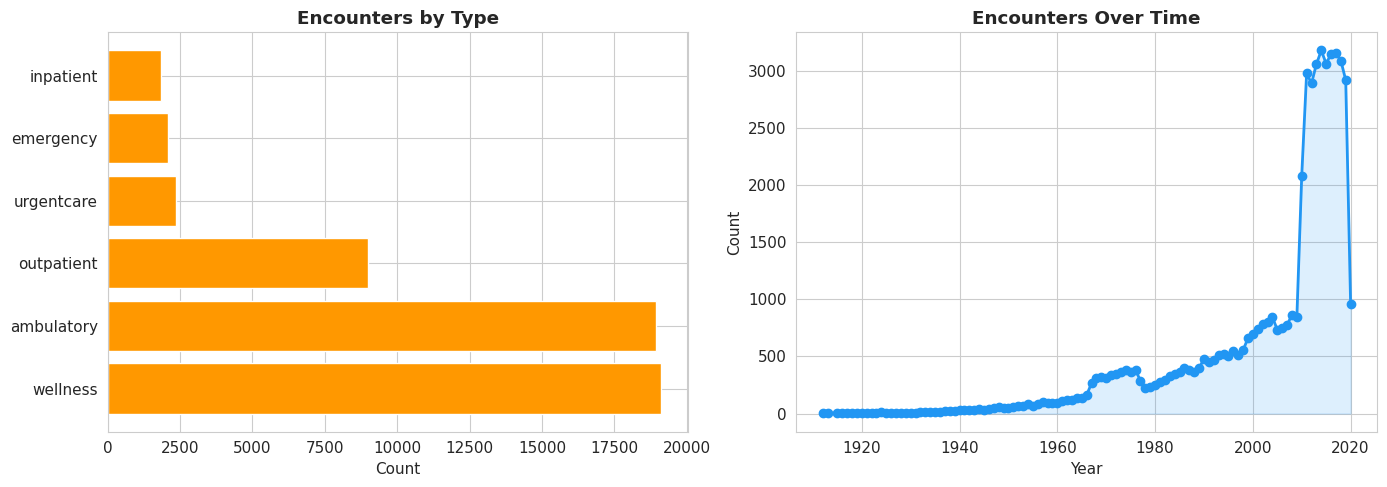


Total encounters: 53,346
Encounter types: {'wellness': np.int64(19106), 'ambulatory': np.int64(18936), 'outpatient': np.int64(9003), 'urgentcare': np.int64(2373), 'emergency': np.int64(2090), 'inpatient': np.int64(1838)}

Financial Summary:
  Total billed:     $  6,868,312.95
  Payer covered:    $  3,307,391.57
  Patient liability: $  3,560,921.38

Saved: images/04_encounters_overview.png


In [11]:
encounters = datasets['encounters'].copy()
encounters['START'] = pd.to_datetime(encounters['START'])
encounters['YEAR'] = encounters['START'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Encounter class distribution
enc_class = encounters['ENCOUNTERCLASS'].value_counts()
axes[0].barh(enc_class.index, enc_class.values, color='#FF9800', edgecolor='white')
axes[0].set_title('Encounters by Type', fontweight='bold')
axes[0].set_xlabel('Count')

# Encounters over time (by year)
yearly = encounters.groupby('YEAR').size()
axes[1].plot(yearly.index, yearly.values, marker='o', color='#2196F3', linewidth=2)
axes[1].fill_between(yearly.index, yearly.values, alpha=0.15, color='#2196F3')
axes[1].set_title('Encounters Over Time', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../../images/04_encounters_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Financial snapshot
print(f"\nTotal encounters: {len(encounters):,}")
print(f"Encounter types: {dict(enc_class)}")
print(f"\nFinancial Summary:")
print(f"  Total billed:     ${encounters['TOTAL_CLAIM_COST'].sum():>14,.2f}")
print(f"  Payer covered:    ${encounters['PAYER_COVERAGE'].sum():>14,.2f}")
print(f"  Patient liability: ${(encounters['TOTAL_CLAIM_COST'] - encounters['PAYER_COVERAGE']).sum():>14,.2f}")
print(f"\nSaved: images/04_encounters_overview.png")

### 10. Top Clinical Conditions

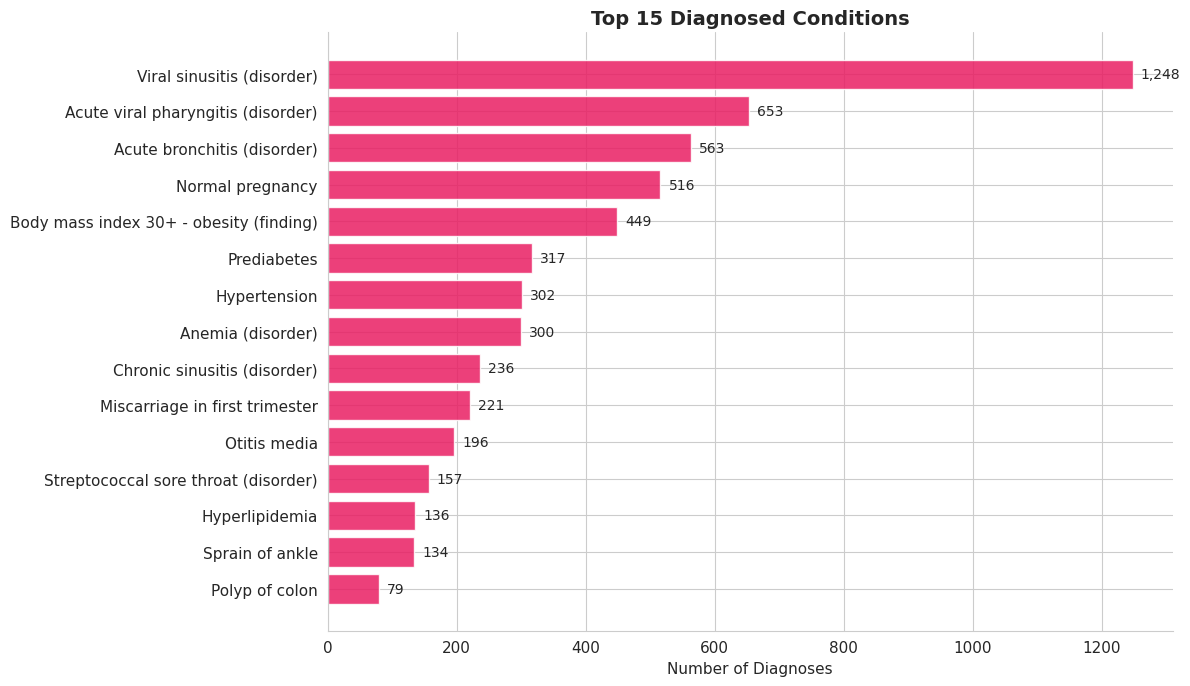

Total condition records: 8,376
Unique conditions: 129

Saved: images/05_top_conditions.png


In [12]:
conditions = datasets['conditions'].copy()
top_conditions = conditions['DESCRIPTION'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_conditions.index[::-1], top_conditions.values[::-1], 
               color='#E91E63', edgecolor='white', alpha=0.85)
ax.set_title('Top 15 Diagnosed Conditions', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Diagnoses')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, top_conditions.values[::-1]):
    ax.text(bar.get_width() + max(top_conditions.values)*0.01, 
            bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../../images/05_top_conditions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Total condition records: {len(conditions):,}")
print(f"Unique conditions: {conditions['DESCRIPTION'].nunique()}")
print(f"\nSaved: images/05_top_conditions.png")

### 11. Phase 1 Summary & Key Findings

#### Dataset Scope
- **16 CSV files** covering patients, encounters, conditions, medications, observations, procedures, and more
- **1,171 patients** with demographic data spanning birth to present
- **53,346 encounters** — the central transactional table linking all clinical data
- **299,697 observations** — the largest table by volume (lab results, vitals, etc.)

#### Data Quality Assessment
- Referential integrity is strong — patient and encounter keys align across tables
- Null values are concentrated in expected optional fields (STOP dates for ongoing conditions, DEATHDATE for living patients)
- `supplies.csv` is empty (0 rows) — will be excluded from subsequent analysis

#### Entity Relationships Confirmed
- `patients` → `encounters` (via PATIENT = Id) — the primary join path
- `encounters` → `conditions`, `medications`, `procedures`, `observations` (via ENCOUNTER = Id)
- `encounters` → `organizations`, `providers`, `payers` (via foreign keys)
- `payer_transitions` tracks insurance changes over time per patient

#### Ready for Phase 2
The data is clean, well-structured, and relational. Phase 2 will set up a SQL database, load these tables, and run the exploratory queries defined in the project plan.

---
*Notebook: `01_data_profiling.ipynb` | Phase 1 of 5 | Healthcare Analytics Project*
